# John Cena Timeline

In [2]:
# libraries
import matplotlib.pyplot as plt
from matplotlib.image import imread
from matplotlib.patches import Patch
import duckdb
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm # install for fonts
fonts = sorted([f.name for f in fm.fontManager.ttflist])
print([f for f in fonts if any(x in f.lower() for x in ["gothic", "impact", "bold", "black"])])

['Apple SD Gothic Neo', 'AppleGothic', 'Arial Black', 'Arial Rounded MT Bold', 'Hiragino Maru Gothic Pro', 'Impact', 'Noto Sans Gothic']


In [2]:
conn = duckdb.connect("/Users/marietolteca/Documents/MEDS/WWE-database/wwe_database.db")
cur = conn.cursor()

### SQL Query

In [3]:
cur.execute("""
SELECT 
    s.superstar_name,
    YEAR(m.Date) AS Year,
    m.CageMatchRating
FROM superstars s
JOIN match_rating m ON s.MatchIndex = m.Index
JOIN events e ON e.Date = m.Date AND e.Promotion = m.Promotion
WHERE s.superstar_name ILIKE '%cena%'
  AND m.CageMatchRating IS NOT NULL
ORDER BY Year ASC;
""")

### View dataframe

In [4]:
# Save query from all superstars in Wrestlemania with most viewed total votes
df = cur.df()

# Print the first five rows
df

,superstar_name,Year,CageMatchRating
0,John Cena,2015,3.91
1,John Cena,2015,3.91
2,John Cena,2015,3.91
3,John Cena,2015,7.38
4,John Cena,2015,7.38
...,...,...,...
188,John Cena,2025,4.51
189,John Cena,2025,6.20
190,John Cena,2025,3.29
191,John Cena,2025,3.29


### Label Timeline &  Plot

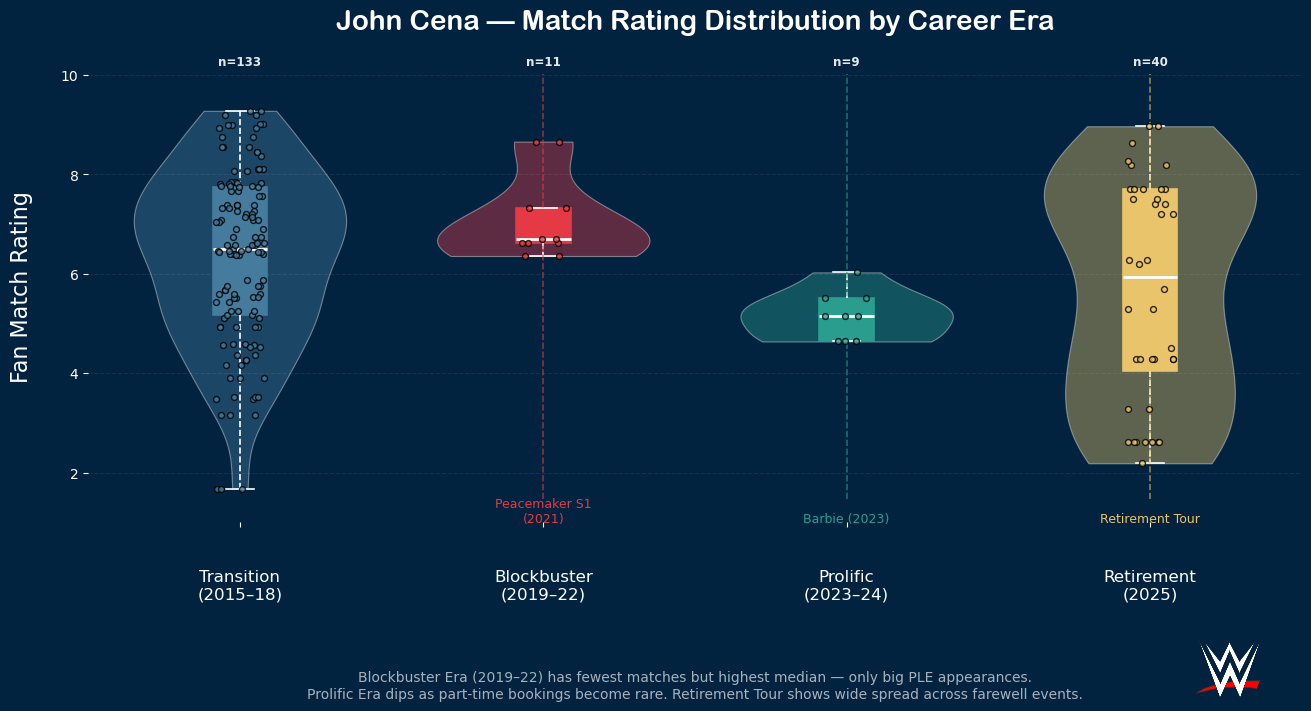

In [ ]:
# Manually set Timeline
era_order = [
    "Transition to Film\n(2015–2018)",
    "Blockbuster Era\n(2019–2022)",
    "Prolific Era\n(2023–2024)",
    "Retirement Tour\n(2025)"
]

df["Era"] = df["Year"].apply(get_era)

era_data   = [df[df["Era"] == e]["CageMatchRating"].values for e in era_order]
era_colors = ["#457b9d", "#e63946", "#2a9d8f", "#e9c46a"]
era_labels_short = ["Transition\n(2015–18)", "Blockbuster\n(2019–22)", "Prolific\n(2023–24)", "Retirement\n(2025)"]

bg_color = "#022340"

fig, ax = plt.subplots(figsize=(13, 7), constrained_layout=True)
# remove plt.tight_layout() call entirely
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Violin plots
parts = ax.violinplot(era_data, positions=range(len(era_order)), widths=0.7,
                      showmedians=False, showextrema=False)

for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(era_colors[i])
    pc.set_alpha(0.4)
    pc.set_edgecolor("white")
    pc.set_linewidth(0.8)

# Box plot overlay
bp = ax.boxplot(era_data, positions=range(len(era_order)), widths=0.18,
                patch_artist=True, showfliers=False,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="white", linewidth=1.2, linestyle="--"),
                capprops=dict(color="white", linewidth=1.2),
                boxprops=dict(linewidth=1.2))


for patch, color in zip(bp["boxes"], era_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)

# Jittered points
for i, data in enumerate(era_data):
    jitter = np.random.uniform(-0.08, 0.08, size=len(data))
    #points
    ax.scatter(np.full(len(data), i) + jitter, data,
               color=era_colors[i], alpha=0.8, s=18, zorder=3,
               edgecolors="black")

# Annotations — key Hollywood moments
# Vertical marker at bottom of each violin
for x, label, color in [(1, "Peacemaker S1\n(2021)", "#e63946"),
                         (2, "Barbie (2023)",          "#2a9d8f"),
                         (3, "Retirement Tour",        "#e9c46a")]:
    ax.axvline(x=x, ymin=0.05, ymax=0.95, color=color, lw=1.2, linestyle="--", alpha=0.6)
    ax.text(x, 1.0, label, ha="center", fontsize=9, color=color)



# Sample size labels: n= #
for i, data in enumerate(era_data):
    ax.text(i, 10.2, f"n={len(data)}", ha="center", fontsize=8.5, color="white", alpha=0.9, fontweight="bold")

ax.set_xticks(range(len(era_order)))
ax.set_xticklabels(era_labels_short, color="white", fontsize=12)

ax.set_ylabel("Fan Match Rating", color="white", fontsize=16, labelpad=20)

ax.set_ylim(1, 10.5)
ax.set_title("John Cena — Match Rating Distribution by Career Era",
             color="white", fontsize=20, fontweight="bold", pad=15,
             # Set font
             #fontfamily="Hiragino Maru Gothic Pro",
             fontfamily="Arial Rounded MT Bold")


ax.tick_params(colors="white")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(axis="y", color="white", alpha=0.07, linestyle="--")


# Add padding between x tick labels and annotation text
ax.tick_params(axis="x", pad=30)  # pushes era labels down



# Hollywood note
ax.set_xlabel(
    "Blockbuster Era (2019–22) has fewest matches but highest median — only big PLE appearances.\n"
    "Prolific Era dips as part-time bookings become rare. Retirement Tour shows wide spread across farewell events.",
    color="white", fontsize=10, alpha=0.65, labelpad=50
)


# Add LOGO
logo = imread("WWE-logo.png")
logo_ax = fig.add_axes([0.90, -0.15, 0.08, 0.4])  # [left, bottom, width, height]
logo_ax.imshow(logo)
logo_ax.axis("off")
plt.savefig('johncena_timeline.png', dpi=150)

plt.show()